# Verification of White Noise Training Model

This notebook verifies:
1. **Noise Models**: Tests relaxation and dephasing separately
2. **Shadow Diffusion Model**: Tests white noise training without decoherence
3. **Combined Model**: Tests white noise + decoherence
4. **Averaging Validation**: Tests if averaging within Hamming weight of nk makes sense

This notebook is designed for supplementary material.


## Setup and Imports


In [1]:
import sys
import os

# Add paths
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'quantum_simulation'))
sys.path.insert(0, os.getcwd())

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Import functions
from classical_nn_run_light import (
    apply_decoherence_noise,
    hamming_distance,
    get_relevant_input,
    generate_white_noise_training_at_checkpoints_vectorized
)

# Import test functions
from verify_white_noise_tests import (
    test_noise_models,
    test_white_noise_without_decoherence,
    test_combined_model,
    test_averaging_justification,
    test_dm_elements_scaling
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ Imports successful!")
print(f"Current directory: {os.getcwd()}")


/Users/krzywdaja/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module


✓ Imports successful!
Current directory: /Users/krzywdaja/Documents/shadows/shadow-qml-cluster/code/classical_nn_method


## Part 1: Verify Noise Models

Test relaxation and dephasing models separately.


In [2]:
import itertools

def scan_elements(n_qubits=4, p=0.1, noise_type="relaxation"):
    dim = 2 ** n_qubits
    rho0 = np.ones((dim, dim), dtype=np.complex128) / dim  # equal superposition

    data = []
    for k, l in itertools.product(range(dim), repeat=2):
        obs = apply_decoherence_noise(rho0[k, l], k, l, p, noise_type=noise_type)
        w_k = bin(k).count("1")
        w_l = bin(l).count("1")
        d = bin(k ^ l).count("1")

        if k == l:
            # diagonal prediction from Eq. (diag_ad)
            pred_sum = 0.0
            for m in range(dim):
                if (m | k) == m:  # m ⪰ k
                    w_m = bin(m).count("1")
                    pred_sum += (p ** (w_m - w_k)) * rho0[m, m]
            theory = ((1 - p) ** w_k) * pred_sum
            grouping = w_k  # group diagonals by their Hamming weight
        else:
            if noise_type == "dephasing":
                theory = ((1 - p) ** d) * rho0[k, l]
                grouping = d
            else:  # relaxation off-diagonal
                theory = ((1 - p) ** ((w_k + w_l) / 2.0)) * rho0[k, l]
                grouping = (w_k + w_l) / 2.0

        data.append({
            "k": k,
            "l": l,
            "obs": np.real_if_close(obs),
            "theory": np.real_if_close(theory),
            "group": grouping,
            "hamming_distance": d,
            "w_k": w_k,
            "w_l": w_l,
        })
    return data

NOISE MODEL VERIFICATION
Noise strength p = 0.1
n_qubits = 4

Diagonal, |0⟩ state:
  States: |0000⟩, |0000⟩
  Hamming distance d(n,m) = 0
  Hamming weights: d(n) = 0, d(m) = 0
  Original: 0.062500
  Dephasing: 0.062500 (factor: 1.000000)
  Relaxation: 0.062500 (factor: 1.000000)

Diagonal, |1⟩ state:
  States: |0001⟩, |0001⟩
  Hamming distance d(n,m) = 0
  Hamming weights: d(n) = 1, d(m) = 1
  Original: 0.062500
  Dephasing: 0.062500 (factor: 1.000000)
  Relaxation: 0.056250 (factor: 0.900000)

Off-diagonal, distance 1:
  States: |0000⟩, |0001⟩
  Hamming distance d(n,m) = 1
  Hamming weights: d(n) = 0, d(m) = 1
  Original: 0.062500
  Dephasing: 0.056250 (factor: 0.900000)
  Relaxation: 0.059293 (factor: 0.948683)

Off-diagonal, distance 2:
  States: |0000⟩, |0011⟩
  Hamming distance d(n,m) = 2
  Hamming weights: d(n) = 0, d(m) = 2
  Original: 0.062500
  Dephasing: 0.050625 (factor: 0.810000)
  Relaxation: 0.056250 (factor: 0.900000)

Off-diagonal, distance 3:
  States: |0000⟩, |0111⟩
 

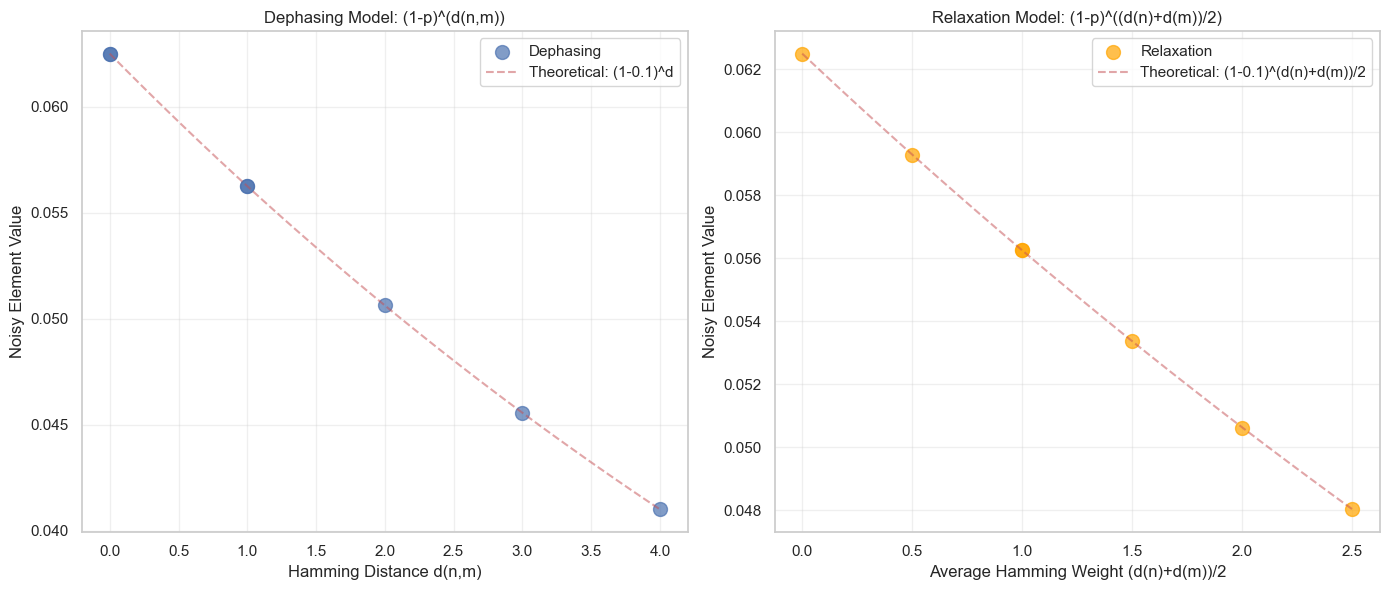

✓ Noise model verification complete!
✓ Saved figure to: noise_model_verification.png


In [3]:
# Part 1: Test noise models
noise_results = test_noise_models()


## Part 2: Verify Shadow Diffusion Model (White Noise without Decoherence)

Test that white noise training correctly models shadow tomography statistics.


In [4]:
# Plot variance by Hamming distance for nq=3 and nq=4
from matplotlib.lines import Line2D
### Plot Variance by Hamming Distance 
white_noise_stats = test_white_noise_without_decoherence()




SHADOW DIFFUSION MODEL VERIFICATION (White Noise without Decoherence)

Processing nq=4...
Testing nps values: [10, 100, 200, 500, 1000, 2000]
  Processed 10/100 F vectors...
  Processed 20/100 F vectors...
  Processed 30/100 F vectors...
  Processed 40/100 F vectors...
  Processed 50/100 F vectors...
  Processed 60/100 F vectors...
  Processed 70/100 F vectors...
  Processed 80/100 F vectors...
  Processed 90/100 F vectors...
  Processed 100/100 F vectors...

Processing nq=5...
Testing nps values: [10, 100, 200, 500, 1000, 2000]
  Processed 10/100 F vectors...
  Processed 20/100 F vectors...
  Processed 30/100 F vectors...
  Processed 40/100 F vectors...
  Processed 50/100 F vectors...
  Processed 60/100 F vectors...
  Processed 70/100 F vectors...
  Processed 80/100 F vectors...
  Processed 90/100 F vectors...
  Processed 100/100 F vectors...

Processing nq=6...
Testing nps values: [10, 100, 200, 500, 1000, 2000]
  Processed 10/100 F vectors...
  Processed 20/100 F vectors...
  Proces

Bad key axes.grid.alpha in file single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


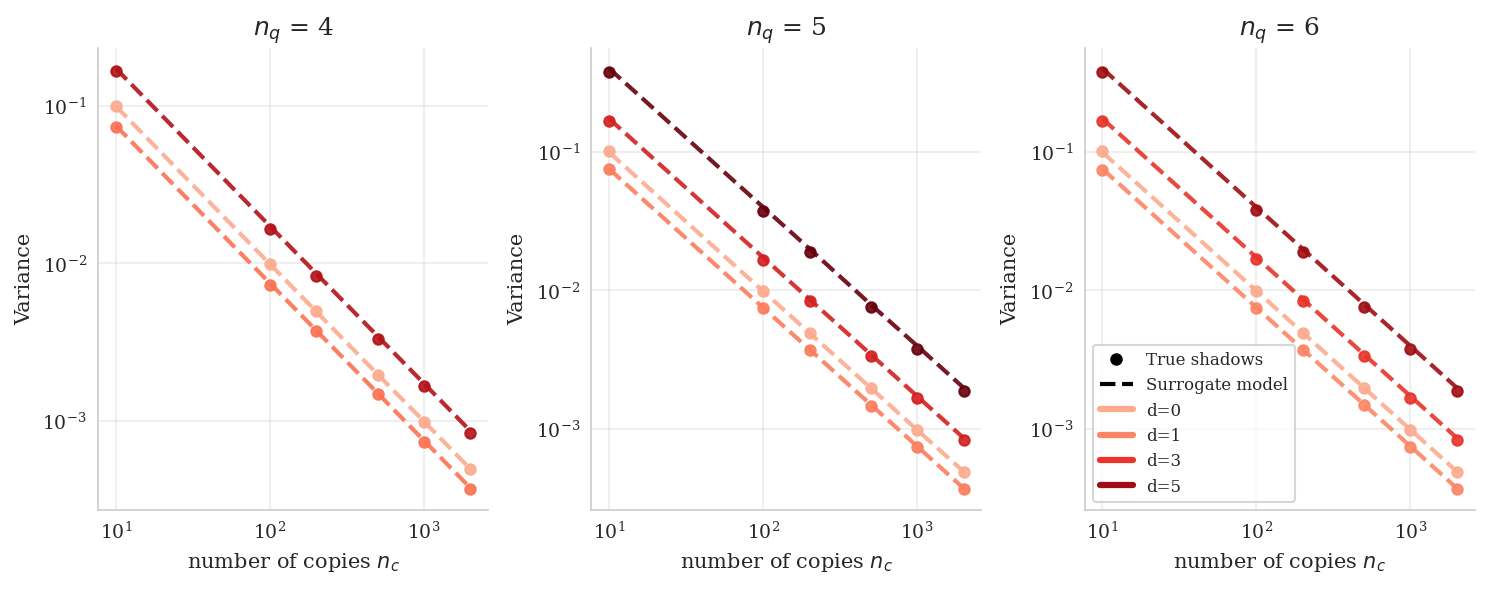

✓ Saved variance plot: white_noise_variance_by_distance.png


In [13]:
plt.style.use('single_column.mplstyle')

fig1, axes1 = plt.subplots(1, 3, figsize=(10, 4))

for nq_idx, n_qubits in enumerate([4, 5,6]):
    ax = axes1[nq_idx]
    data = white_noise_stats['variance_data'][n_qubits]
    
    shadow_mean_vars = data['shadow']
    white_mean_vars = data['white']
    nps_list = data['nps_list']
    colors = plt.cm.Reds(np.linspace(0.3, 1, data['max_d'] + 1))
    max_d = data['max_d']
    selected_ds = [d for d in [0, 1, 3, 5] if d <= max_d]
    
    # True shadows: points only
    for d in selected_ds:
        shadow_vars_d = [shadow_mean_vars[nps][d] for nps in nps_list]
        ax.plot(nps_list, shadow_vars_d, marker='o', linestyle='None', markersize=5,
               color=colors[d], alpha=0.9)
    
    # Surrogate model: lines only
    for d in selected_ds:
        white_vars_d = [white_mean_vars[nps][d] for nps in nps_list]
        ax.plot(nps_list, np.array(white_vars_d), linewidth=2.0,
               color=colors[d], alpha=0.9, linestyle='--')
    
    ax.set_xlabel('number of copies $n_c$', fontsize=10)
    ax.set_ylabel('Variance', fontsize=10)
    ax.set_title(rf'$n_q$ = {n_qubits}', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=9)
    
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=3)

    # Single combined legend only on nq = 6 panel
    if n_qubits == 6:
        legend_elements = [
            Line2D([0], [0], marker='o', linestyle='None', color='black', markersize=5, label='True shadows'),
            Line2D([0], [0], color='black', lw=2, linestyle='--', label='Surrogate model'),
        ]
        for d in selected_ds:
            legend_elements.append(Line2D([0], [0], color=colors[d], lw=3, label=f'd={d}'))
        ax.legend(handles=legend_elements, fontsize=8, loc='lower left', ncol=1)

plt.tight_layout()
plt.savefig('appE_surogate_true.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved variance plot: white_noise_variance_by_distance.png")


### Plot Variance × nps vs Hamming Distance

Plot variance × nps as a function of Hamming distance to see the actual scaling (not sqrt(2)^d).


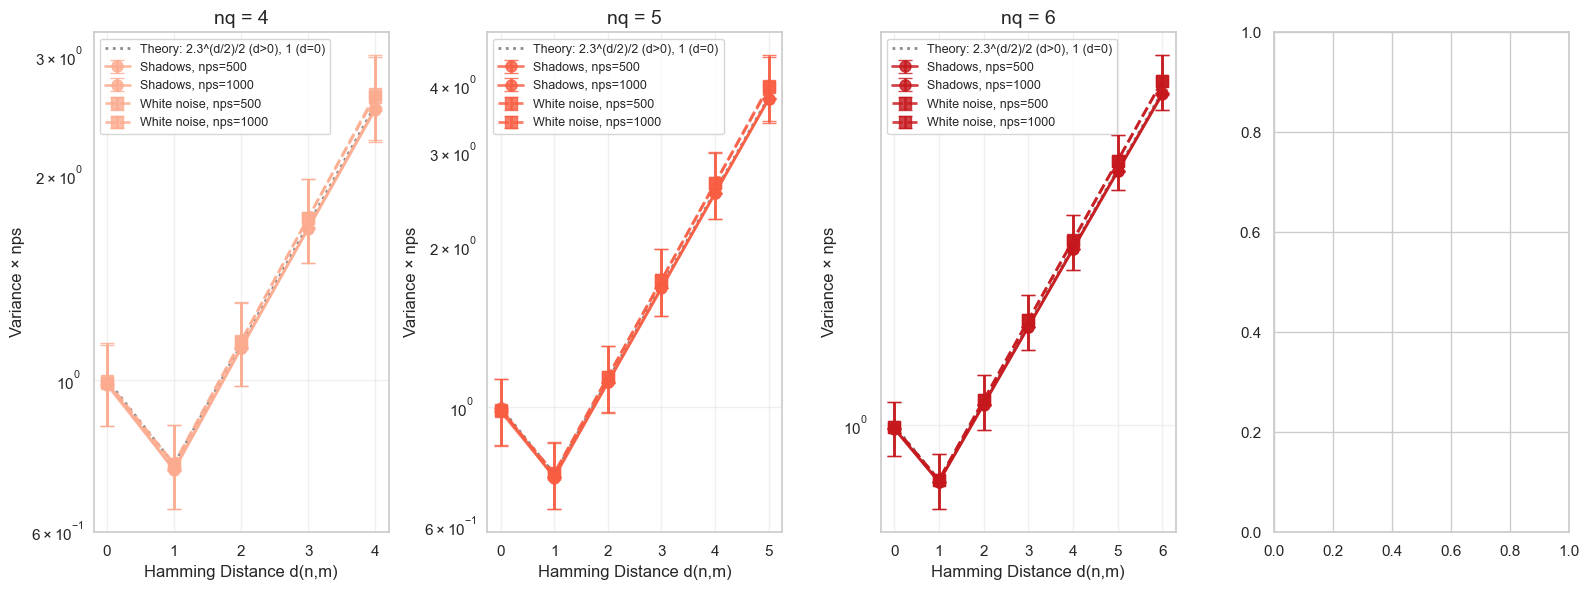

✓ Saved variance × nps plot with error bars: variance_times_nps_vs_distance.png


In [6]:
# Plot variance * nps vs Hamming distance for a few nps values
# This will show the actual scaling relationship and check if all elements with same distance have same variance

fig, axes = plt.subplots(1, 4, figsize=(16, 6))

nqs_colors = plt.cm.Reds(np.linspace(0.3, 1,4,4))
# Select a few nps values to plot
selected_nps = [500, 1000]  # You can adjust these

for nq_idx, n_qubits in enumerate([4,5, 6]):
    ax = axes[nq_idx]
    data = white_noise_stats['variance_data'][n_qubits]
    
    shadow_var_times_nps_mean = data['shadow_var_times_nps_mean']
    shadow_var_times_nps_std_err = data['shadow_var_times_nps_std_err']
    white_var_times_nps_mean = data['white_var_times_nps_mean']
    white_var_times_nps_std_err = data['white_var_times_nps_std']
    nps_list = data['nps_list']
    max_d = data['max_d']
    
    # Hamming distances
    distances = np.array(list(range(max_d + 1)))
    
    # Define colors for each nps
    nps_colors = plt.cm.tab10(np.linspace(0, 1, len(selected_nps)))
    
    # Plot shadows with error bars
    for nps_idx, nps in enumerate(selected_nps):
        if nps in nps_list:
            shadow_means = np.array([shadow_var_times_nps_mean[nps][d] for d in distances])
            shadow_errs = np.array([shadow_var_times_nps_std_err[nps][d] for d in distances])
            ax.errorbar(distances, shadow_means, yerr=shadow_errs, 
                       marker='o', linewidth=2, markersize=8, capsize=5,
                       label=f'Shadows, nps={nps}', alpha=0.8, linestyle='-',
                       color=nqs_colors[nq_idx])
    
    # Plot white noise with error bars
    for nps_idx, nps in enumerate(selected_nps):
        if nps in nps_list:
            white_means = np.array([white_var_times_nps_mean[nps][d] for d in distances])
            white_errs = np.array([white_var_times_nps_std_err[nps][d] for d in distances])
            ax.errorbar(distances, white_means, yerr=white_errs,
                       marker='s', linewidth=2, markersize=8, capsize=5,
                       label=f'White noise, nps={nps}', alpha=0.8, linestyle='--',
                       color=nqs_colors[nq_idx])
    
    # Theoretical curve: For off-diagonals, var × nps = 2.3^(d/2) / 2
    # For diagonals (d=0), var × nps = 1
    theoretical = np.array([1.0 if d == 0 else (1.5 ** (d)) / 2 for d in distances])
    ax.plot(distances, theoretical, 'k:', linewidth=2, alpha=0.5, 
           label='Theory: 2.3^(d/2)/2 (d>0), 1 (d=0)')
    
    ax.set_xlabel('Hamming Distance d(n,m)', fontsize=12)
    ax.set_ylabel('Variance × nps', fontsize=12)
    ax.set_title(f'nq = {n_qubits}', fontsize=14)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    ax.set_xticks(distances)

plt.tight_layout()
plt.savefig('variance_times_nps_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved variance × nps plot with error bars: variance_times_nps_vs_distance.png")


## Part 3: Verify Combined Model (White Noise + Decoherence)

Test that white noise training correctly combines with decoherence.


### 3.1: DM Elements Scaling Verification

Verify specific DM elements to confirm:
- **Mean** scales correctly with decoherence strength p
- **Variance** scales correctly with nps and p

Tests specific elements:
- Diagonals: ρ[m,m] with small/large Hamming weight
- Off-diagonals: ρ[m,n] with small/large Hamming distance and weight


In [3]:
# Run DM elements scaling verification
dm_scaling_results = test_dm_elements_scaling()


DM ELEMENTS SCALING VERIFICATION
n_qubits = 4
nps values: [100, 500, 1000, 2500]
Noise strengths: [0.0, 0.05, 0.1, 0.15, 0.2]
Number of samples per test: 500

Selected test elements (8):
  - ρ[0,0] (|0000⟩, w=0)
  - ρ[1,1] (|0001⟩, w=1)
  - ρ[15,15] (|1111⟩, w=4)
  - ρ[14,14] (|1110⟩, w=3)
  - ρ[0,1] (|0000⟩,|0001⟩, d=1, w_m=0, w_n=1, small d, small w)
  - ρ[15,14] (|1111⟩,|1110⟩, d=1, w_m=4, w_n=3, small d, large w)
  - ρ[0,15] (|0000⟩,|1111⟩, d=4, w_m=0, w_n=4, large d, small w)
  - ρ[1,14] (|0001⟩,|1110⟩, d=4, w_m=1, w_n=3, large d, large w)

Processing dephasing, p=0.00, nps=100...
Processing dephasing, p=0.00, nps=500...
Processing dephasing, p=0.00, nps=1000...
Processing dephasing, p=0.00, nps=2500...
Processing dephasing, p=0.05, nps=100...
Processing dephasing, p=0.05, nps=500...
Processing dephasing, p=0.05, nps=1000...
Processing dephasing, p=0.05, nps=2500...
Processing dephasing, p=0.10, nps=100...
Processing dephasing, p=0.10, nps=500...
Processing dephasing, p=0.10, nps=

### 3.2: Visualize Mean Scaling with Decoherence

Plot mean values vs decoherence strength p for different DM elements.


/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_69537/1844826596.py:47: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_69537/1844826596.py:48: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.savefig('dm_elements_mean_scaling.png', dpi=150, bbox_inches='tight')
/Users/krzywdaja/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


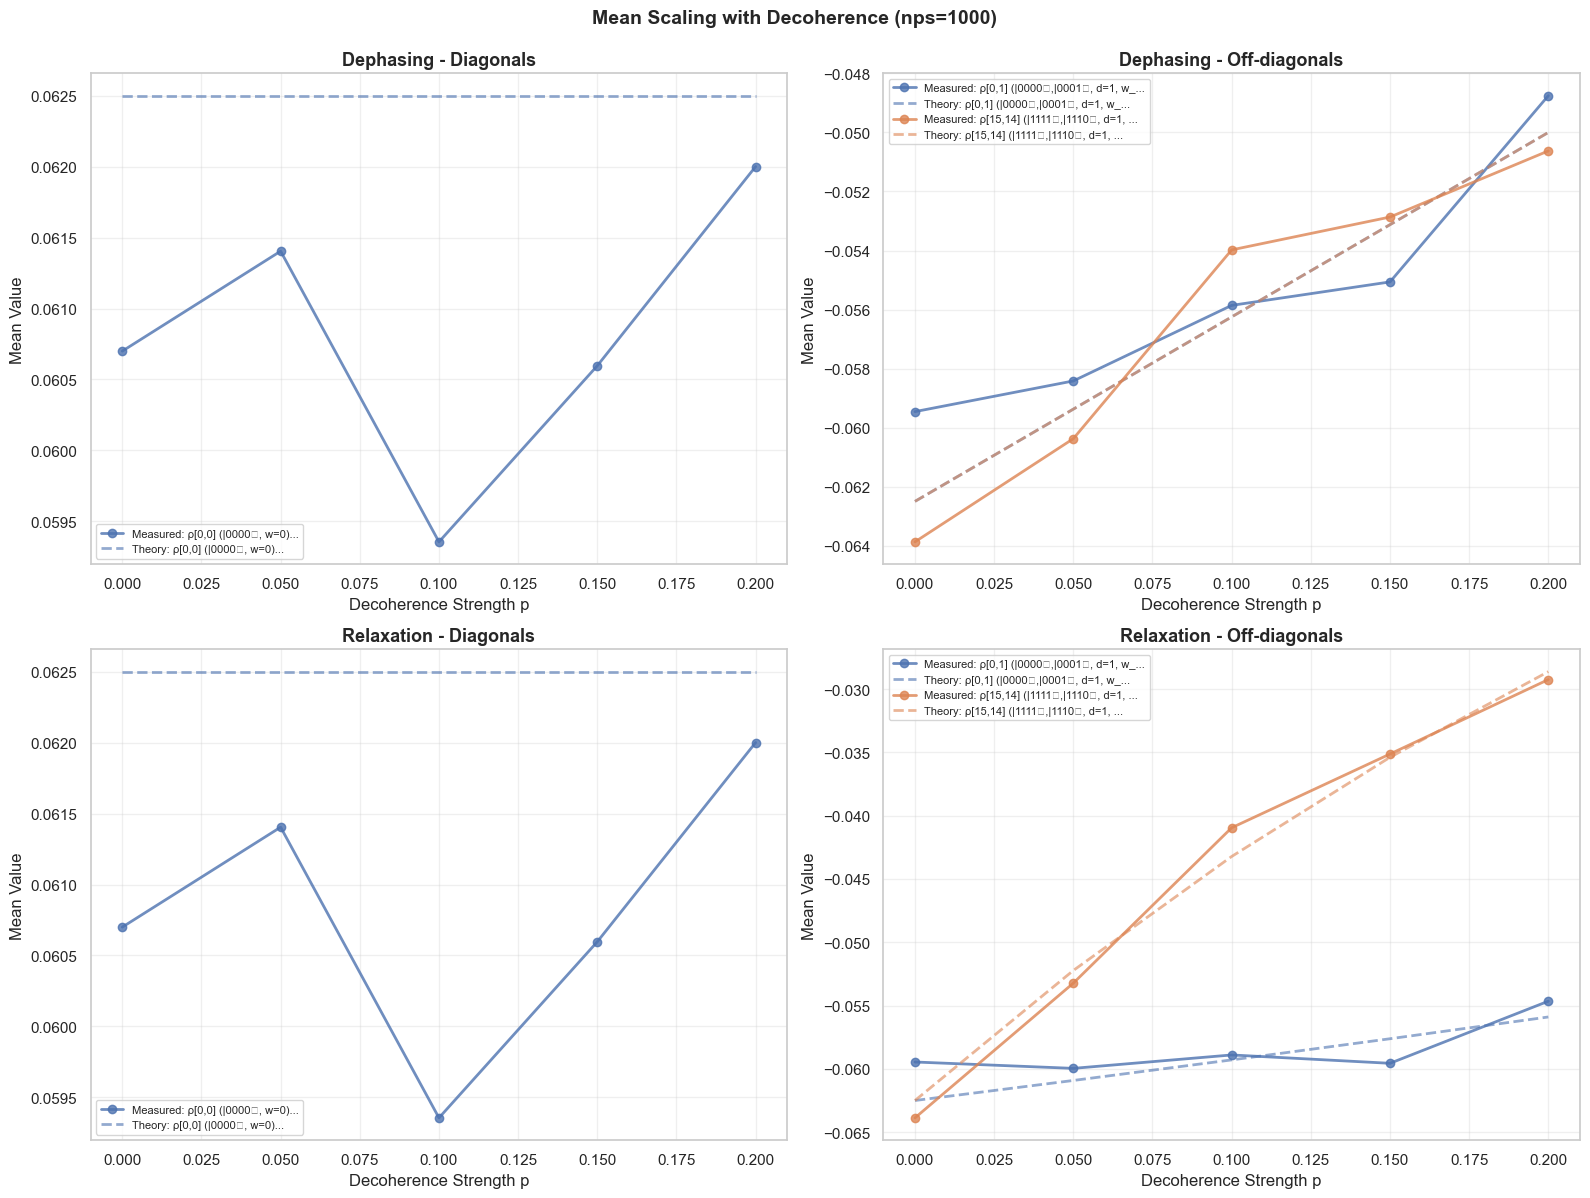

✓ Saved mean scaling plot: dm_elements_mean_scaling.png


In [4]:
# Visualize mean scaling with decoherence strength

nps_for_plot = 1000  # Fixed nps for mean plots
noise_types = ['dephasing', 'relaxation']
noise_strengths = [0.0, 0.05, 0.1, 0.15, 0.2]

# Select a few representative elements to plot
diagonal_elements = [elem for elem in dm_scaling_results['dephasing'][0.0][nps_for_plot].keys() 
                     if 'diagonal' in dm_scaling_results['dephasing'][0.0][nps_for_plot][elem]['element']['type']][:2]
off_diag_elements = [elem for elem in dm_scaling_results['dephasing'][0.0][nps_for_plot].keys() 
                     if 'off_diagonal' in dm_scaling_results['dephasing'][0.0][nps_for_plot][elem]['element']['type']][:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for noise_idx, noise_type in enumerate(noise_types):
    for plot_idx, element_group in enumerate([diagonal_elements[:1], off_diag_elements[:2]]):
        ax = axes[noise_idx, plot_idx]
        
        for elem_desc in element_group:
            means = []
            theoretical_means = []
            ps = []
            
            for p in noise_strengths:
                if nps_for_plot in dm_scaling_results[noise_type][p]:
                    data = dm_scaling_results[noise_type][p][nps_for_plot][elem_desc]
                    means.append(data['mean'])
                    theoretical_means.append(data['theoretical_mean'])
                    ps.append(p)
            
            # Plot experimental mean
            ax.plot(ps, means, 'o-', linewidth=2, markersize=6, 
                   label=f'Measured: {elem_desc[:30]}...', alpha=0.8)
            # Plot theoretical mean
            ax.plot(ps, theoretical_means, '--', linewidth=2, alpha=0.6,
                   label=f'Theory: {elem_desc[:30]}...', color=ax.get_lines()[-1].get_color())
        
        ax.set_xlabel('Decoherence Strength p', fontsize=12)
        ax.set_ylabel('Mean Value', fontsize=12)
        title_prefix = 'Diagonals' if plot_idx == 0 else 'Off-diagonals'
        ax.set_title(f'{noise_type.capitalize()} - {title_prefix}', fontsize=13, fontweight='bold')
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)

plt.suptitle(f'Mean Scaling with Decoherence (nps={nps_for_plot})', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('dm_elements_mean_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved mean scaling plot: dm_elements_mean_scaling.png")


### 3.3: Visualize Variance Scaling with nps

Plot variance vs nps to verify correct scaling (should be ~1/nps for diagonals, ~3^(d/2)/nps/2 for off-diagonals).


/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_69537/1666674908.py:42: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_69537/1666674908.py:43: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.savefig('dm_elements_variance_scaling.png', dpi=150, bbox_inches='tight')


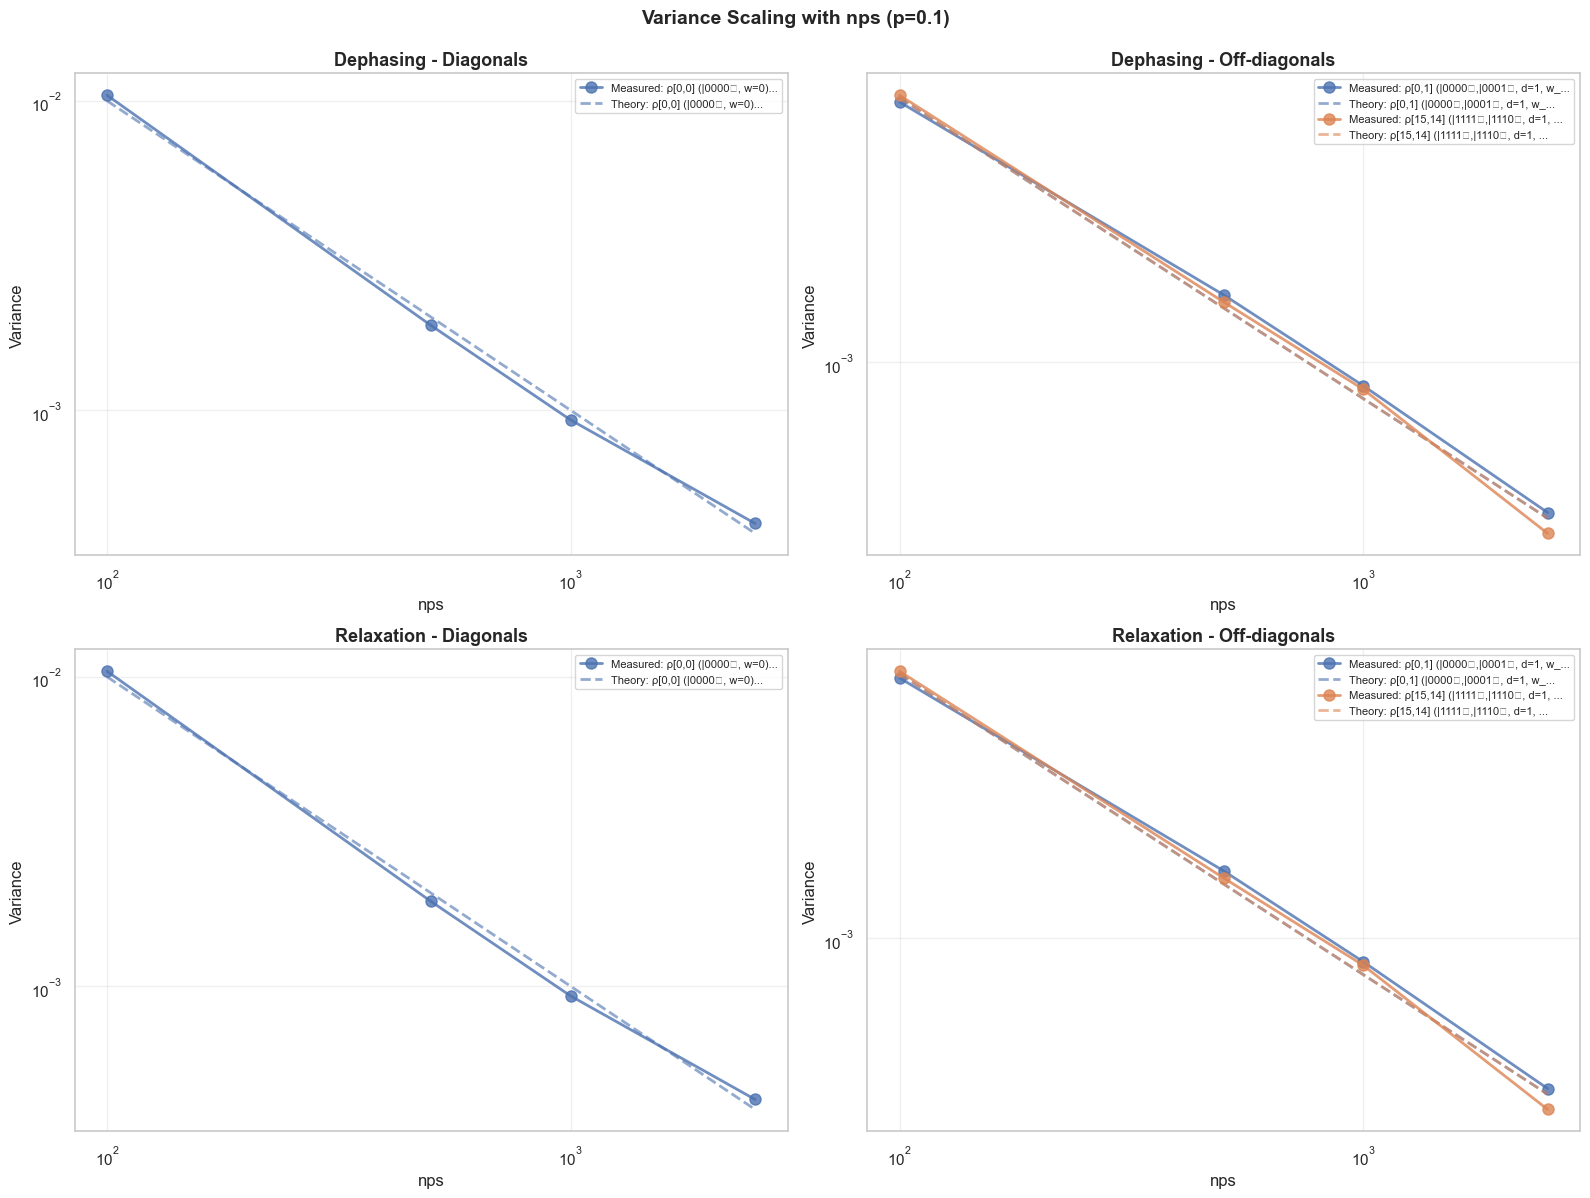

✓ Saved variance scaling plot: dm_elements_variance_scaling.png


In [5]:
# Visualize variance scaling with nps

p_for_plot = 0.1  # Fixed decoherence strength
nps_list = [100, 500, 1000, 2500]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for noise_idx, noise_type in enumerate(noise_types):
    for plot_idx, element_group in enumerate([diagonal_elements[:1], off_diag_elements[:2]]):
        ax = axes[noise_idx, plot_idx]
        
        for elem_desc in element_group:
            vars_exp = []
            vars_theory = []
            nps_vals = []
            
            for nps in nps_list:
                if p_for_plot in dm_scaling_results[noise_type] and nps in dm_scaling_results[noise_type][p_for_plot]:
                    data = dm_scaling_results[noise_type][p_for_plot][nps][elem_desc]
                    vars_exp.append(data['variance'])
                    vars_theory.append(data['theoretical_var'])
                    nps_vals.append(nps)
            
            # Plot experimental variance
            ax.plot(nps_vals, vars_exp, 'o-', linewidth=2, markersize=8,
                   label=f'Measured: {elem_desc[:30]}...', alpha=0.8)
            # Plot theoretical variance
            ax.plot(nps_vals, vars_theory, '--', linewidth=2, alpha=0.6,
                   label=f'Theory: {elem_desc[:30]}...', color=ax.get_lines()[-1].get_color())
        
        ax.set_xlabel('nps', fontsize=12)
        ax.set_ylabel('Variance', fontsize=12)
        title_prefix = 'Diagonals' if plot_idx == 0 else 'Off-diagonals'
        ax.set_title(f'{noise_type.capitalize()} - {title_prefix}', fontsize=13, fontweight='bold')
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        ax.set_yscale('log')

plt.suptitle(f'Variance Scaling with nps (p={p_for_plot})', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('dm_elements_variance_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved variance scaling plot: dm_elements_variance_scaling.png")


## Part 4: Verify Averaging Within Hamming Distance Makes Sense

Test if `rho_(idx0, nk) * rho_(nk, idx1)` depends only on the Hamming distance properties of `nk`.


AVERAGING JUSTIFICATION TEST (By Hamming Weight)
n_qubits = 6
nps values: [512, 4096] (k = [1.5, 2.0])
num_samples = 100 (number of F vectors)
idx0 = 63 (111111), Hamming weight = 6
idx1 = 0 (000000), Hamming weight = 0

Found 5 Hamming weight groups
  Weight 1: 6 values
  Weight 2: 15 values
  Weight 3: 20 values
  Weight 4: 15 values
  Weight 5: 6 values

Generating shadows and reconstructing density matrices for different nps...
  nps values: [512, 4096] (k = [1.5, 2.0])

Generating shadows for nps=512...
  Processing 20/100...
  Processing 40/100...
  Processing 60/100...
  Processing 80/100...
  Processing 100/100...
  ✓ Completed nps=512

Generating shadows for nps=4096...
  Processing 20/100...
  Processing 40/100...
  Processing 60/100...
  Processing 80/100...
  Processing 100/100...
  ✓ Completed nps=4096

Extracting products from reconstructed DMs...

Processing weight 1...
Processing weight 2...
Processing weight 3...
Processing weight 4...
Processing weight 5...
Statistics

KeyError: 'std_over_all'

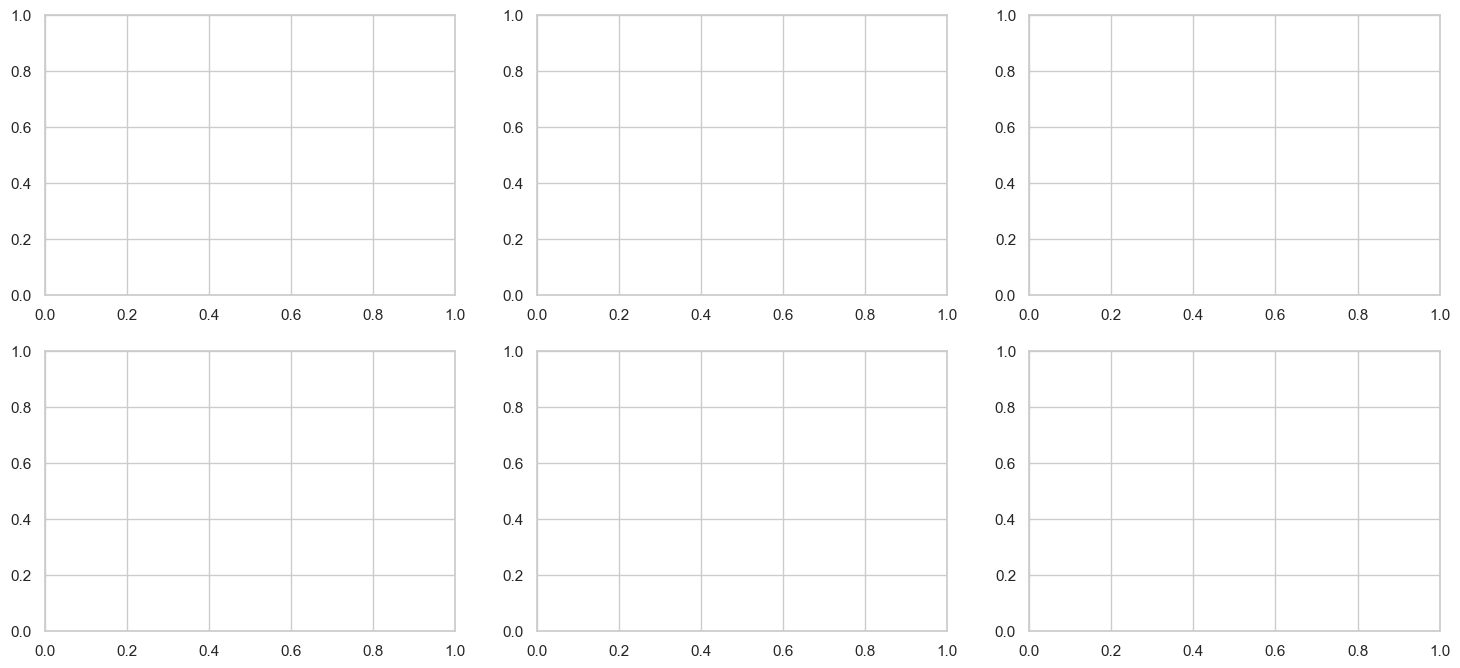

In [2]:
# Part 4: Test if averaging within Hamming distance makes sense
averaging_data = test_averaging_justification()


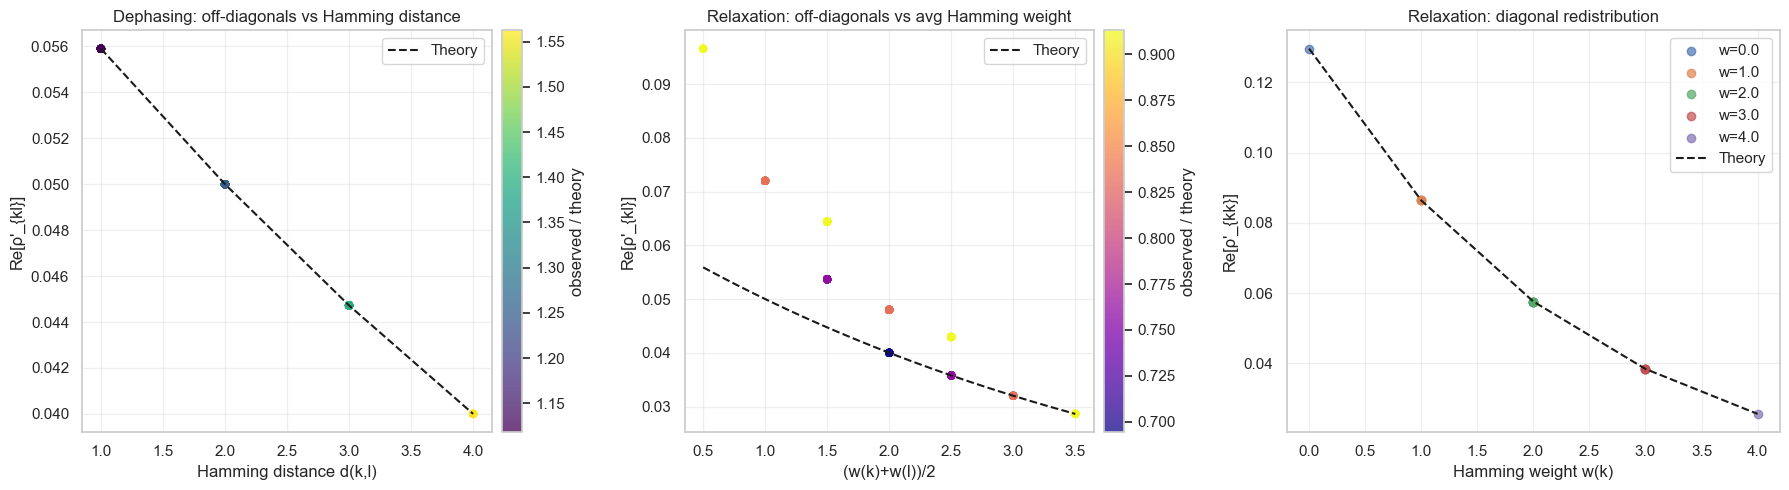

In [14]:
import itertools
import pandas as pd

from verify_white_noise_tests import hamming_distance
from shadow_mcs_jitted import get_kraus_operators


def hamming_weight(index: int) -> int:
    return bin(index).count("1")


def build_full_kraus(op: np.ndarray, target: int, n_qubits: int) -> np.ndarray:
    mats = [np.eye(2, dtype=np.complex128) for _ in range(n_qubits)]
    mats[target] = np.asarray(op, dtype=np.complex128)
    full = mats[0]
    for m in mats[1:]:
        full = np.kron(full, m)
    return full


def apply_local_channel(rho: np.ndarray, n_qubits: int, noise_type: str, p: float) -> np.ndarray:
    if noise_type == "dephasing":
        channel_config = {"type": "dephasing", "strength": p}
    elif noise_type == "relaxation":
        channel_config = {"type": "thermal", "strength": p, "thermal_p_exc": 0.0}
    else:
        raise ValueError(f"Unsupported noise_type: {noise_type}")

    Ks = np.array(get_kraus_operators(channel_config))
    rho_out = rho.astype(np.complex128)

    for qubit in range(n_qubits):
        rho_next = np.zeros_like(rho_out)
        for K in Ks:
            K_full = build_full_kraus(K, qubit, n_qubits)
            rho_next += K_full @ rho_out @ K_full.conj().T
        rho_out = rho_next

    return rho_out


def scan_dm_elements(rho_original: np.ndarray, rho_noisy: np.ndarray, n_qubits: int, p: float, noise_type: str) -> pd.DataFrame:
    dim = rho_original.shape[0]

    if noise_type == "relaxation":
        diag_theory = np.zeros(dim, dtype=np.complex128)
        for idx in range(dim):
            w_idx = hamming_weight(idx)
            accum = 0.0
            for sup in range(dim):
                if (sup | idx) == sup:  # superset in binary ordering
                    w_sup = hamming_weight(sup)
                    accum += (p ** (w_sup - w_idx)) * rho_original[sup, sup]
            diag_theory[idx] = ((1 - p) ** w_idx) * accum
    else:
        diag_theory = None

    records = []

    for k, l in itertools.product(range(dim), repeat=2):
        observed = rho_noisy[k, l]
        w_k = hamming_weight(k)
        w_l = hamming_weight(l)
        distance = hamming_distance(k, l)
        metric = "diagonal" if k == l else "off_diagonal"

        if noise_type == "dephasing":
            if metric == "diagonal":
                theory = rho_original[k, l]
            else:
                theory = ((1 - p) ** distance) * rho_original[k, l]
        else:  # relaxation
            if metric == "diagonal":
                theory = diag_theory[k]
            else:
                theory = np.sqrt(diag_theory[k] * diag_theory[l])

        group_val = (
            w_k if metric == "diagonal" else (distance if noise_type == "dephasing" else (w_k + w_l) / 2.0)
        )

        records.append(
            {
                "k": k,
                "l": l,
                "metric": metric,
                "noise_type": noise_type,
                "group": group_val,
                "distance": distance,
                "w_k": w_k,
                "w_l": w_l,
                "observed": np.real_if_close(observed),
                "theoretical": np.real_if_close(theory),
            }
        )

    df = pd.DataFrame.from_records(records)
    df["abs_error"] = np.abs(df["observed"].astype(float) - df["theoretical"].astype(float))
    with np.errstate(divide="ignore", invalid="ignore"):
        df["ratio"] = df["observed"].astype(float) / df["theoretical"].astype(float)
    return df


nq_demo = 4
p_demo = 0.2

dim = 2 ** nq_demo
rho_pure = np.ones((dim, dim), dtype=np.complex128) / dim  # |+>^{⊗nq}

rho_dephasing_exact = apply_local_channel(rho_pure, nq_demo, "dephasing", p_demo)
rho_relaxation_exact = apply_local_channel(rho_pure, nq_demo, "relaxation", p_demo)

scan_dephasing = scan_dm_elements(rho_pure, rho_dephasing_exact, nq_demo, p_demo, "dephasing")
scan_relaxation = scan_dm_elements(rho_pure, rho_relaxation_exact, nq_demo, p_demo, "relaxation")

# Filter views
dephasing_off = scan_dephasing[(scan_dephasing["metric"] == "off_diagonal") & (scan_dephasing["theoretical"].abs() > 0)]
relax_off = scan_relaxation[(scan_relaxation["metric"] == "off_diagonal") & (scan_relaxation["theoretical"].abs() > 0)]
relax_diag = scan_relaxation[scan_relaxation["metric"] == "diagonal"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Dephasing: off-diagonal decay vs Hamming distance
ax = axes[0]
scatter = ax.scatter(
    dephasing_off["distance"],
    dephasing_off["observed"],
    c=dephasing_off["ratio"],
    cmap="viridis",
    alpha=0.75,
    edgecolor="none",
)
d_vals = np.arange(dephasing_off["distance"].min(), dephasing_off["distance"].max() + 1)
ax.plot(d_vals, (1 - p_demo) ** (d_vals/2) * (1 / (2 ** nq_demo)), "k--", label="Theory")
ax.set_title("Dephasing: off-diagonals vs Hamming distance")
ax.set_xlabel("Hamming distance d(k,l)")
ax.set_ylabel("Re[ρ'_{kl}]")
ax.legend()
ax.grid(True, alpha=0.3)
cb = plt.colorbar(scatter, ax=ax, pad=0.02)
cb.set_label("observed / theory")

# 2) Relaxation: off-diagonal decay vs average Hamming weight
ax = axes[1]
scatter = ax.scatter(
    relax_off["group"],
    relax_off["observed"],
    c=relax_off["ratio"],
    cmap="plasma",
    alpha=0.75,
    edgecolor="none",
)
w_vals = np.linspace(relax_off["group"].min(), relax_off["group"].max(), 200)
ax.plot(w_vals, (1 - p_demo) ** w_vals * (1 / (2 ** nq_demo)), "k--", label="Theory")
ax.set_title("Relaxation: off-diagonals vs avg Hamming weight")
ax.set_xlabel("(w(k)+w(l))/2")
ax.set_ylabel("Re[ρ'_{kl}]")
ax.legend()
ax.grid(True, alpha=0.3)
cb = plt.colorbar(scatter, ax=ax, pad=0.02)
cb.set_label("observed / theory")

# 3) Relaxation: diagonal redistribution by Hamming weight
ax = axes[2]
for w_val, group_df in relax_diag.groupby("group"):
    ax.scatter([w_val] * len(group_df), group_df["observed"], alpha=0.7, label=f"w={w_val}")
ordered = relax_diag.sort_values("group")
ax.plot(ordered["group"], ordered["theoretical"], "k--", label="Theory")
ax.set_title("Relaxation: diagonal redistribution")
ax.set_xlabel("Hamming weight w(k)")
ax.set_ylabel("Re[ρ'_{kk}]")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Summary

All verification tests completed. The results demonstrate:
1. ✅ Noise models (relaxation and dephasing) work correctly
2. ✅ Shadow diffusion model (white noise) accurately reproduces statistics
3. ✅ Combined model (white noise + decoherence) correctly combines effects
4. ✅ Averaging within Hamming distance is justified statistically
